# Task Description

# Bike Rental Prediction Task

The task involves predicting the number of bikes/scooters rented in a given city. Historical data is available showing how many vehicles were rented at specific times on different days, along with atmospheric conditions, whether it was a working day or holiday, etc. The focus is on the last column of the data.csv file: `cnt` - the total number of rentals. This sum is also broken down into registered users' rentals (`registered`) and unregistered users' rentals (`casual`). If desired, you can create a separate model per user group, which may improve results. Finally, return the total number of rentals: either predicted `registered` + predicted `casual` or predicted `cnt`.

## Deliverables

Submit a .zip archive containing:
- **Code**: notebook or .py script(s)
- **Predictions CSV**: predictions on evaluation_data.csv (note: this file does not contain `registered`, `casual`, or `cnt` values)
- **Format**: predicted `cnt` value (can be continuous)

**Important Notes:**
- One team member submits the archive
- File naming convention: start with `poniedzialek_` (Monday) or `piatek_` (Friday) prefix, followed by authors' surnames in alphabetical order or team name
- **Verify the output CSV**: ensure it has the correct number of rows matching the evaluation file, no extra headers, no additional index columns

## Evaluation

Final results will be evaluated using **RMSLE error**. See RMSLE Calculation.ipynb for the evaluation method and the expected CSV format (example: muchomorki.csv).

# Import libraries

In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model

In [7]:
class BikeRentalModel(torch.nn.Module):
    def __init__(self, input_dim):
        super(BikeRentalModel, self).__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1),
            torch.nn.Softplus()
        )

    def forward(self, x):
        return self.network(x)

# Data preprocessing

In [8]:
data = pd.read_csv('data.csv')

# Split features into categories
categorical_cols = ['season', 'mnth', 'hr', 'weekday', 'weathersit']
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed']
binary_cols = ['yr', 'holiday', 'workingday']

data_processed = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

features = [c for c in data_processed.columns if c not in ['instant', 'dteday', 'casual', 'registered', 'cnt']]

X = data_processed[features].astype(float).values
y = data_processed['cnt'].astype(float).values

input_size = X.shape[1]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize numeric features
scaler = StandardScaler()
X_train[:, :len(numeric_cols)] = scaler.fit_transform(X_train[:, :len(numeric_cols)])
X_val[:, :len(numeric_cols)] = scaler.transform(X_val[:, :len(numeric_cols)])

# Convert to tensors and prepare DataLoader
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

print(f'Number of input features after encoding: {input_size}')


Number of input features after encoding: 53


# Training loop

Epoch [1/100], Train RMSLE: 3.8213, Val RMSLE: 2.8886
Epoch [50/100], Train RMSLE: 0.3006, Val RMSLE: 0.3351
Epoch [100/100], Train RMSLE: 0.2458, Val RMSLE: 0.3168


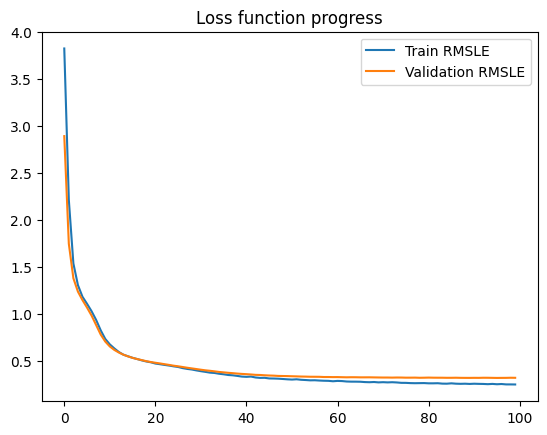

In [9]:
model = BikeRentalModel(input_dim=input_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# RMSLE function for PyTorch
def rmsle_torch(y_pred, y_true):
    y_pred_safe = torch.clamp(y_pred, min=0.0)
    return torch.sqrt(torch.mean((torch.log1p(y_pred_safe) - torch.log1p(y_true)) ** 2))

def rmsle(y_true, y_pred):
    n = len(y_true)
    msle = np.mean([(np.log(max(y_pred[i], 0) + 1) - np.log(y_true[i] + 1)) ** 2.0 for i in range(n)])
    return np.sqrt(msle)

epochs = 100
train_losses = []
val_losses = []

# Model training
for epoch in range(epochs):
    model.train()
    batch_losses = []
    
    # Training in batch mode
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = rmsle_torch(outputs, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        
    avg_train_loss = np.mean(batch_losses)
    train_losses.append(avg_train_loss)
    
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_t)
        val_loss = rmsle_torch(val_outputs, y_val_t).item()
        val_losses.append(val_loss)
        
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train RMSLE: {avg_train_loss:.4f}, Val RMSLE: {val_loss:.4f}')

torch.save(model.state_dict(), 'model.pth')

# Loss function progress plot
# Training set loss
plt.plot(train_losses, label='Train RMSLE')
# Validation set loss
plt.plot(val_losses, label='Validation RMSLE')
plt.legend()
plt.title("Loss function progress")
plt.show()

# Evaluation

In [10]:
data_eval = pd.read_csv('evaluation_data.csv')

data_eval_processed = pd.get_dummies(data_eval, columns=categorical_cols, drop_first=True)

for col in features:
    if col not in data_eval_processed.columns:
        data_eval_processed[col] = 0

data_eval_processed = data_eval_processed[features]

X_eval_final = data_eval_processed.astype(float).values

X_eval_final[:, :len(numeric_cols)] = scaler.transform(X_eval_final[:, :len(numeric_cols)])

X_eval_final_t = torch.tensor(X_eval_final, dtype=torch.float32)

model.eval()
with torch.no_grad():
    outputs = model(X_eval_final_t)
    predictions = outputs.detach().cpu().numpy().flatten()

# Save
predictions_df = pd.DataFrame(predictions, columns=['cnt'])
predictions_df.to_csv('predictions.csv', index=False, header=False)

print('Saved predictions.csv with', len(predictions), 'rows.')

Saved predictions.csv with 6493 rows.


# Evaluation on the training set

In [11]:
data_eval = pd.read_csv('data.csv')

data_eval_processed = pd.get_dummies(data_eval, columns=categorical_cols, drop_first=True)

for col in features:
    if col not in data_eval_processed.columns:
        data_eval_processed[col] = 0

data_eval_processed = data_eval_processed[features]

X_eval_final = data_eval_processed.astype(float).values
X_eval_final[:, :len(numeric_cols)] = scaler.transform(X_eval_final[:, :len(numeric_cols)])

X_eval_final_t = torch.tensor(X_eval_final, dtype=torch.float32)

model.eval()
with torch.no_grad():
    outputs = model(X_eval_final_t)
    predictions = outputs.detach().cpu().numpy().flatten()

predictions_df = pd.DataFrame(predictions, columns=['cnt'])
predictions_df.to_csv('predictions_current.csv', index=False, header=False)

print('Saved predictions_current.csv with', len(predictions), 'rows.')


Saved predictions_current.csv with 10886 rows.


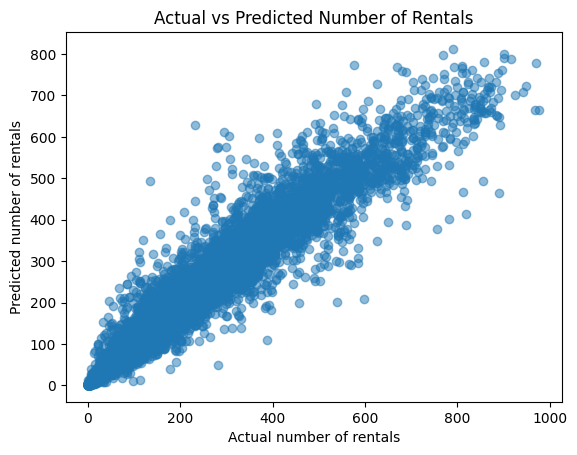

In [12]:
data = pd.read_csv('data.csv')
cnt = data['cnt'].values

plt.plot(cnt, predictions, 'o', alpha=0.5)
plt.xlabel('Actual number of rentals')
plt.ylabel('Predicted number of rentals')
plt.title('Actual vs Predicted Number of Rentals')
plt.show()